# KITTI Dataset EDA

In [1]:
import struct
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg

DATA_DIR = Path('../data/kitti')
SPLITS = ['train', 'val']
CLASS_NAMES = {0: 'Car/Van', 1: 'Pedestrian', 2: 'Cyclist'}

## 1. Dataset size

In [2]:
for split in SPLITS:
    images = list((DATA_DIR / split / 'images').glob('*.png'))
    labels = list((DATA_DIR / split / 'labels').glob('*.txt'))
    print(f'{split}: {len(images)} images, {len(labels)} labels')

train: 3712 images, 3712 labels
val: 3769 images, 3769 labels


## 2. Image sizes

In [3]:
def png_size(path):
    with open(path, 'rb') as f:
        f.read(16)
        w = struct.unpack('>I', f.read(4))[0]
        h = struct.unpack('>I', f.read(4))[0]
    return w, h

size_counts = Counter()
for split in SPLITS:
    for p in (DATA_DIR / split / 'images').glob('*.png'):
        size_counts[png_size(p)] += 1

print('Image size distribution:')
for size, count in size_counts.most_common():
    print(f'  {size[0]}x{size[1]}: {count} images')

Image size distribution:
  1242x375: 6057 images
  1224x370: 770 images
  1238x374: 358 images
  1241x376: 296 images


## 3. Class distribution

In [4]:
class_counts = {split: Counter() for split in SPLITS}
empty_labels = {split: 0 for split in SPLITS}

for split in SPLITS:
    for label_path in (DATA_DIR / split / 'labels').glob('*.txt'):
        lines = [l.strip() for l in label_path.read_text().splitlines() if l.strip()]
        if not lines:
            empty_labels[split] += 1
        for line in lines:
            class_id = int(line.split()[0])
            class_counts[split][class_id] += 1

for split in SPLITS:
    print(f'\n{split}:')
    for cid, name in CLASS_NAMES.items():
        print(f'  {name}: {class_counts[split][cid]}')
    print(f'  Empty labels (no objects of interest): {empty_labels[split]}')


train:
  Car/Van: 15894
  Pedestrian: 2154
  Cyclist: 867
  Empty labels (no objects of interest): 0

val:
  Car/Van: 15762
  Pedestrian: 2333
  Cyclist: 760
  Empty labels (no objects of interest): 0


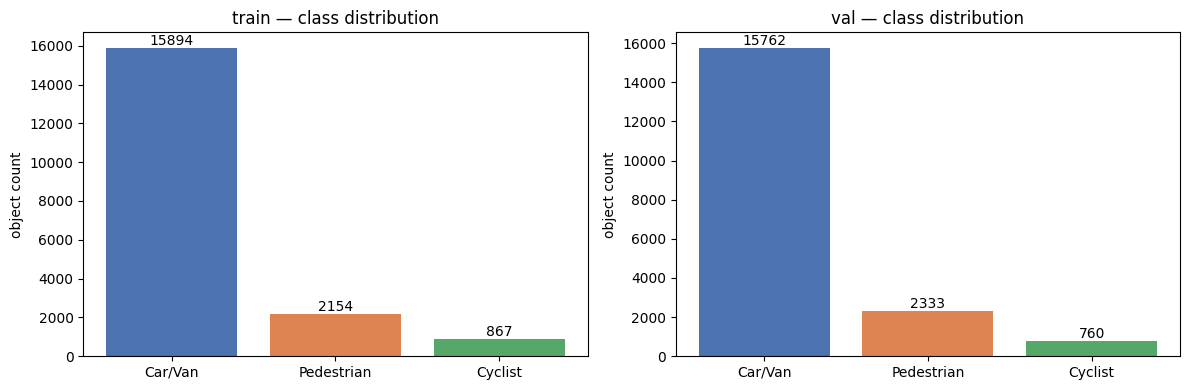

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, SPLITS):
    names = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]
    counts = [class_counts[split][i] for i in sorted(CLASS_NAMES)]
    bars = ax.bar(names, counts, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.bar_label(bars)
    ax.set_title(f'{split} — class distribution')
    ax.set_ylabel('object count')
plt.tight_layout()
plt.show()

## 4. Bounding box size distribution

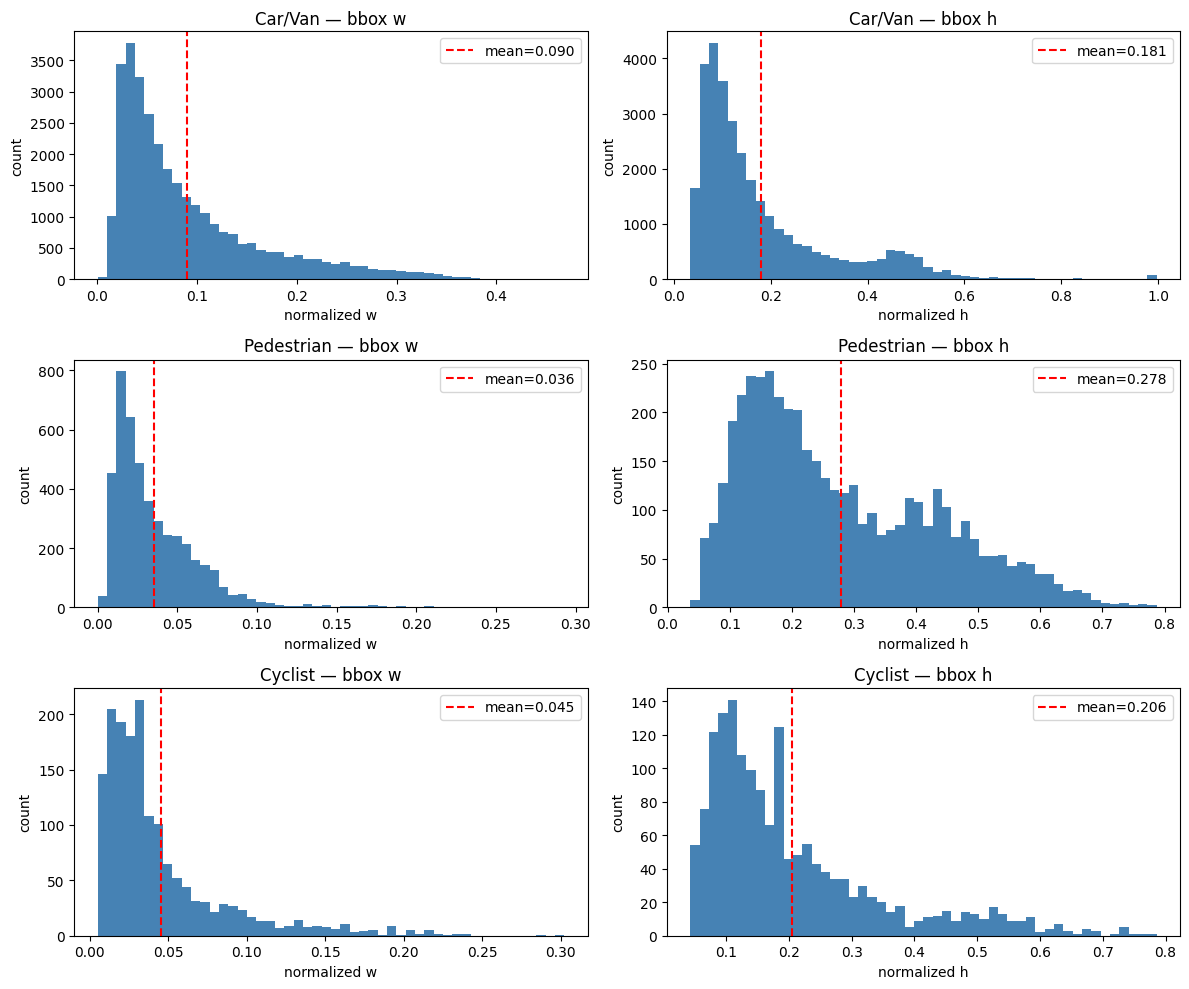

In [6]:
# Collect normalized w, h per class across both splits
bbox_wh = {cid: {'w': [], 'h': []} for cid in CLASS_NAMES}

for split in SPLITS:
    for label_path in (DATA_DIR / split / 'labels').glob('*.txt'):
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cid, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])
            bbox_wh[cid]['w'].append(w)
            bbox_wh[cid]['h'].append(h)

fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(12, 10))
for row, (cid, name) in enumerate(CLASS_NAMES.items()):
    for col, dim in enumerate(['w', 'h']):
        vals = bbox_wh[cid][dim]
        axes[row, col].hist(vals, bins=50, color='steelblue', edgecolor='none')
        axes[row, col].set_title(f'{name} — bbox {dim}')
        axes[row, col].set_xlabel(f'normalized {dim}')
        axes[row, col].set_ylabel('count')
        mean = np.mean(vals) if vals else 0
        axes[row, col].axvline(mean, color='red', linestyle='--', label=f'mean={mean:.3f}')
        axes[row, col].legend()
plt.tight_layout()
plt.show()

## 5. Objects per image

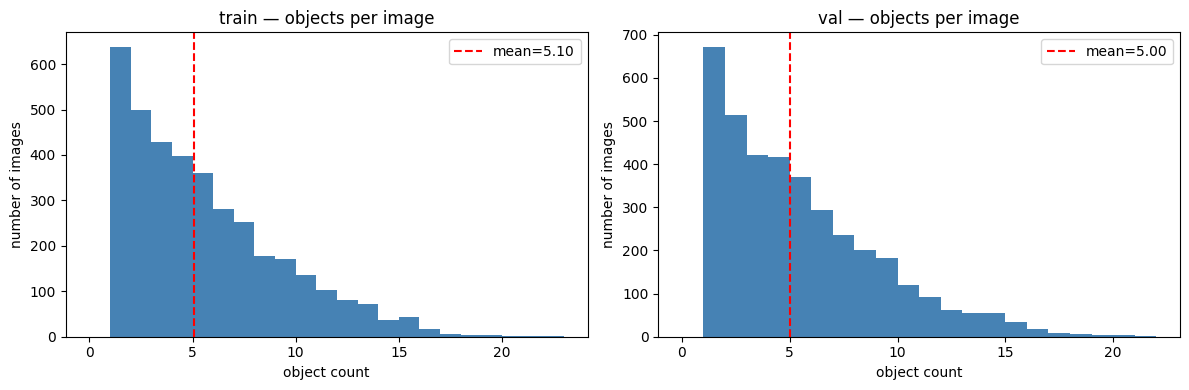

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, SPLITS):
    counts_per_image = []
    for label_path in (DATA_DIR / split / 'labels').glob('*.txt'):
        lines = [l for l in label_path.read_text().splitlines() if l.strip()]
        counts_per_image.append(len(lines))
    ax.hist(counts_per_image, bins=range(0, max(counts_per_image) + 2), color='steelblue', edgecolor='none')
    ax.set_title(f'{split} — objects per image')
    ax.set_xlabel('object count')
    ax.set_ylabel('number of images')
    mean = np.mean(counts_per_image)
    ax.axvline(mean, color='red', linestyle='--', label=f'mean={mean:.2f}')
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Sample images with bounding boxes

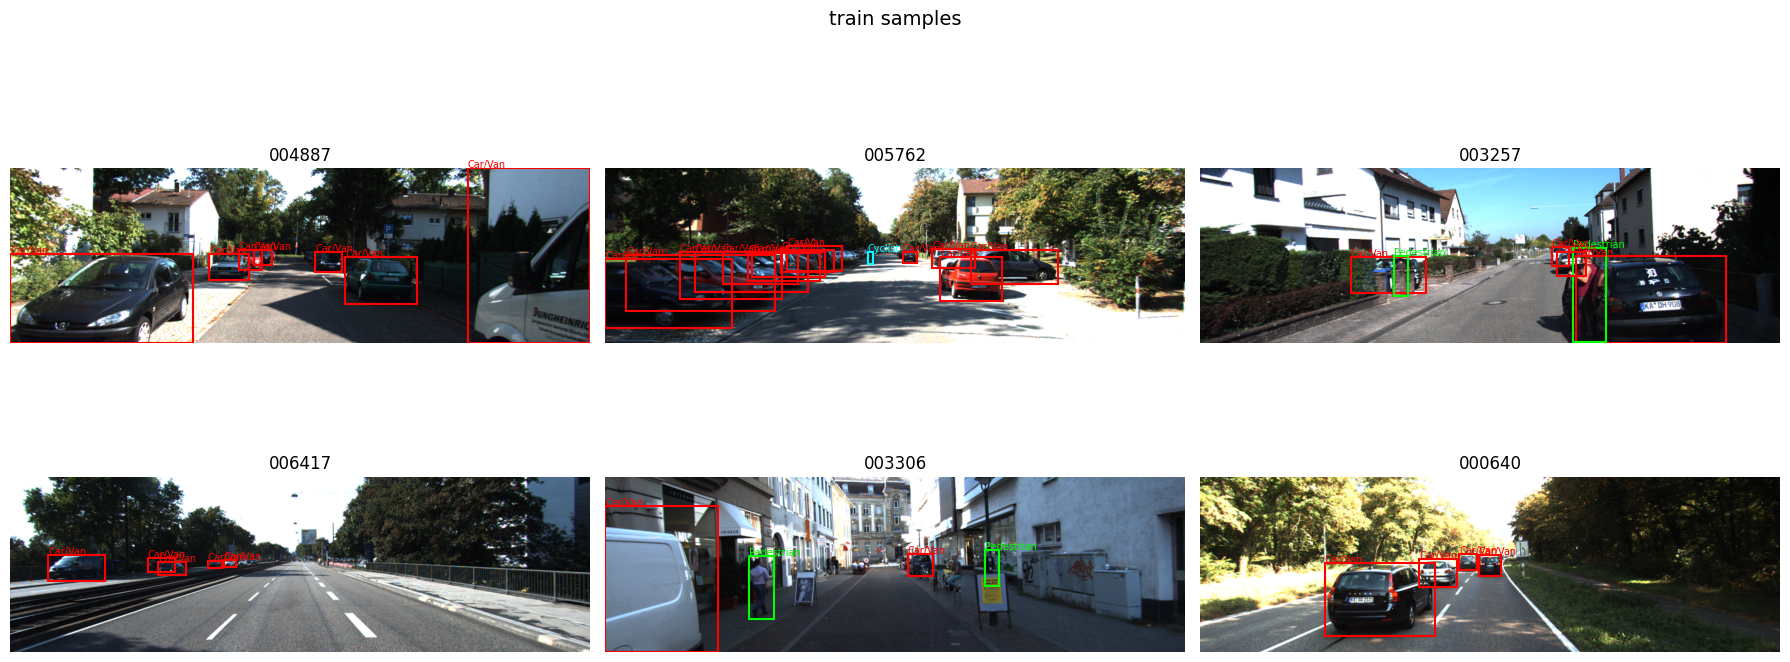

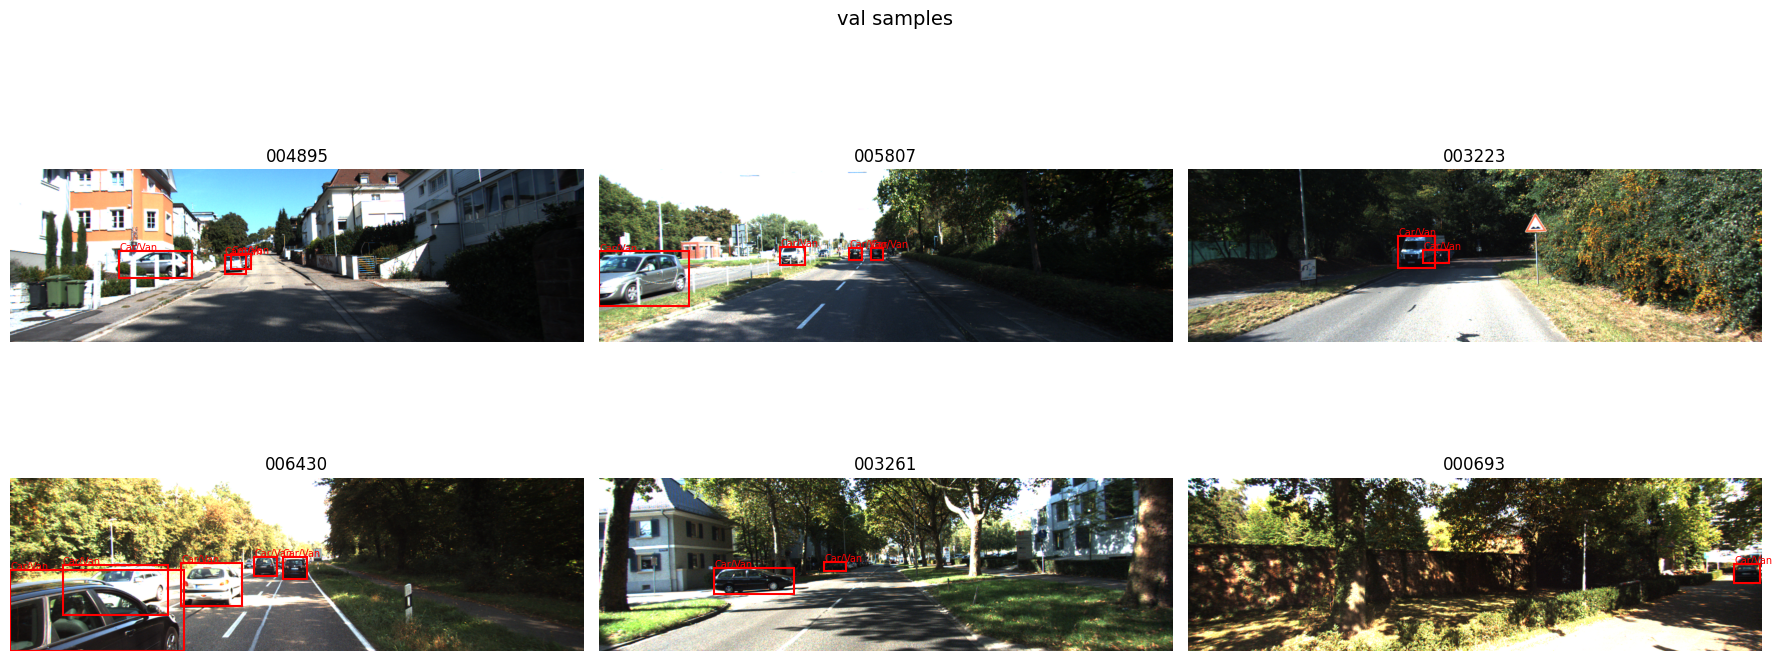

In [8]:
CLASS_COLORS = {0: 'red', 1: 'lime', 2: 'cyan'}

def show_sample(split, n=6):
    images_dir = DATA_DIR / split / 'images'
    labels_dir = DATA_DIR / split / 'labels'

    # Pick images that have at least one label
    candidates = [
        p for p in sorted(labels_dir.glob('*.txt'))
        if p.read_text().strip()
    ]
    rng = np.random.default_rng(42)
    samples = rng.choice(candidates, size=min(n, len(candidates)), replace=False)

    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    for ax, label_path in zip(axes.flat, samples):
        img_path = images_dir / (label_path.stem + '.png')
        img = mpimg.imread(img_path)
        h_img, w_img = img.shape[:2]
        ax.imshow(img)
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cid, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])
            x = (cx - w / 2) * w_img
            y = (cy - h / 2) * h_img
            rect = patches.Rectangle(
                (x, y), w * w_img, h * h_img,
                linewidth=1.5, edgecolor=CLASS_COLORS[cid], facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x, y - 2, CLASS_NAMES[cid], color=CLASS_COLORS[cid], fontsize=7)
        ax.set_title(label_path.stem)
        ax.axis('off')
    plt.suptitle(f'{split} samples', fontsize=14)
    plt.tight_layout()
    plt.show()

show_sample('train')
show_sample('val')